In [84]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, TargetEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
# ==================== 1. LOAD DATA ====================
df = pd.read_csv('../data/data.csv', delimiter=";")


In [85]:
df.columns = df.columns.str.strip().str.replace('\t', '')

# Lihat struktur
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [86]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [87]:

# A. KOLOM NUMERIK ASLI (sudah dalam bentuk benar, tidak perlu diubah)
numeric_columns = [
    'Application order',
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

# B. BINARY ASLI (0/1, sudah benar, tidak perlu diubah)
binary_columns = [
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International',
    'Daytime/evening attendance'  # perhatikan nama ini di df Anda
]

# C. NOMINAL (diencode tapi TIDAK punya urutan) → perlu ditandai atau diubah
# Kolom ini harus diperlakukan sebagai categorical, bukan numeric!
nominal_columns = [
    'Marital status',
    'Application mode',
    'Course',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

# ==================== 3. CEK DATA TYPE ====================
print("Data types:")
print(df.dtypes)




Data types:
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Ge

In [88]:
# ============================================================================
# 3. FEATURE ENGINEERING (BUAT FITUR BARU)
# ============================================================================
print("\n" + "="*60)
print("MELAKUKAN FEATURE ENGINEERING...")
print("="*60)

# ----- RATIO & PERSENTASE -----
df['Success_rate_1st'] = df['Curricular units 1st sem (approved)'] / (df['Curricular units 1st sem (enrolled)'] + 1)
df['Success_rate_2nd'] = df['Curricular units 2nd sem (approved)'] / (df['Curricular units 2nd sem (enrolled)'] + 1)

df['Eval_rate_1st'] = df['Curricular units 1st sem (evaluations)'] / (df['Curricular units 1st sem (enrolled)'] + 1)
df['Eval_rate_2nd'] = df['Curricular units 2nd sem (evaluations)'] / (df['Curricular units 2nd sem (enrolled)'] + 1)

df['Without_eval_rate_1st'] = df['Curricular units 1st sem (without evaluations)'] / (df['Curricular units 1st sem (enrolled)'] + 1)
df['Without_eval_rate_2nd'] = df['Curricular units 2nd sem (without evaluations)'] / (df['Curricular units 2nd sem (enrolled)'] + 1)

# ----- TREND (PERUBAHAN DARI SEMESTER 1 KE 2) -----
df['Grade_improvement'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']
df['Approval_improvement'] = df['Curricular units 2nd sem (approved)'] - df['Curricular units 1st sem (approved)']
df['Eval_improvement'] = df['Curricular units 2nd sem (evaluations)'] - df['Curricular units 1st sem (evaluations)']
df['Success_rate_change'] = df['Success_rate_2nd'] - df['Success_rate_1st']

# ----- FLAGS (KONDISI BERMASALAH) -----
df['Is_failing_1st'] = (df['Curricular units 1st sem (grade)'] < 10).astype(int)
df['Is_failing_2nd'] = (df['Curricular units 2nd sem (grade)'] < 10).astype(int)
df['Low_approval_1st'] = (df['Success_rate_1st'] < 0.5).astype(int)
df['Low_approval_2nd'] = (df['Success_rate_2nd'] < 0.5).astype(int)
df['No_eval_1st'] = (df['Curricular units 1st sem (without evaluations)'] > 0).astype(int)
df['No_eval_2nd'] = (df['Curricular units 2nd sem (without evaluations)'] > 0).astype(int)
df['Dropping_trend'] = ((df['Grade_improvement'] < -1) & (df['Approval_improvement'] < 0)).astype(int)

# ----- ACADEMIC HEALTH SCORE -----
df['Academic_health_1st'] = (
    df['Success_rate_1st'] * 0.4 + 
    (df['Curricular units 1st sem (grade)'] / 20) * 0.4 +
    (1 - df['Without_eval_rate_1st']) * 0.2
)

df['Academic_health_2nd'] = (
    df['Success_rate_2nd'] * 0.4 + 
    (df['Curricular units 2nd sem (grade)'] / 20) * 0.4 +
    (1 - df['Without_eval_rate_2nd']) * 0.2
)

df['Academic_trajectory'] = df['Academic_health_2nd'] - df['Academic_health_1st']

# ----- EKONOMI MAKRO -----
df['Economic_stress'] = df['Unemployment rate'] * df['Inflation rate'] / 100
df['GDP_per_unemployment'] = df['GDP'] / (df['Unemployment rate'] + 1)


MELAKUKAN FEATURE ENGINEERING...


In [89]:
new_numeric = [
    'Success_rate_1st', 'Success_rate_2nd',
    'Eval_rate_1st', 'Eval_rate_2nd',
    'Without_eval_rate_1st', 'Without_eval_rate_2nd',
    'Grade_improvement', 'Approval_improvement', 'Eval_improvement',
    'Success_rate_change',
    'Academic_health_1st', 'Academic_health_2nd', 'Academic_trajectory',
    'Economic_stress', 'GDP_per_unemployment'
]

new_binary = [
    'Is_failing_1st', 'Is_failing_2nd',
    'Low_approval_1st', 'Low_approval_2nd',
    'No_eval_1st', 'No_eval_2nd',
    'Dropping_trend'
]

# Gabungkan dengan kolom asli
numeric_columns = numeric_columns + new_numeric
binary_columns = binary_columns + new_binary

In [90]:
print(f"Total fitur setelah engineering: {len(numeric_columns) + len(binary_columns) + len(nominal_columns)}")
print(f"  - Numerik: {len(numeric_columns)}")
print(f"  - Binary: {len(binary_columns)}")
print(f"  - Nominal: {len(nominal_columns)}")

Total fitur setelah engineering: 58
  - Numerik: 34
  - Binary: 15
  - Nominal: 9


In [91]:
# ============================================================================
# 4. PREPARE X DAN Y
# ============================================================================
X = df[numeric_columns + binary_columns + nominal_columns].copy()
y = df['Target'].copy()

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nTarget mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")


Target mapping: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}


In [92]:

# ============================================================================
# 5. TRAIN TEST SPLIT (WAJIB PERTAMA!)
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 3539, Test size: 885


In [93]:
# ============================================================================
# 6. TARGET ENCODER UNTUK NOMINAL COLUMNS
# ============================================================================
print("\n" + "="*60)
print("MELAKUKAN TARGET ENCODING UNTUK NOMINAL...")
print("="*60)

te = TargetEncoder(target_type='multiclass', random_state=42)

X_train_nominal = te.fit_transform(X_train[nominal_columns], y_train)
X_test_nominal = te.transform(X_test[nominal_columns])

# Gabungkan dengan numeric + binary
X_train_final = np.hstack([
    X_train[numeric_columns + binary_columns].values, 
    X_train_nominal
])
X_test_final = np.hstack([
    X_test[numeric_columns + binary_columns].values, 
    X_test_nominal
])

print(f"Shape X_train_final: {X_train_final.shape}")
print(f"Shape X_test_final: {X_test_final.shape}")


MELAKUKAN TARGET ENCODING UNTUK NOMINAL...
Shape X_train_final: (3539, 76)
Shape X_test_final: (885, 76)


In [94]:
# ============================================================================
# 7. MENCARI CLASS WEIGHT TERBAIK
# ============================================================================
print("\n" + "="*60)
print("MENCARI CLASS WEIGHT TERBAIK UNTUK ENROLLED")
print("="*60)

weight_configs = [
    {0: 1.0, 1: 1.2, 2: 0.9},
    {0: 1.0, 1: 1.4, 2: 0.85},
    {0: 1.0, 1: 1.6, 2: 0.8},
    {0: 0.9, 1: 1.5, 2: 0.8},
    {0: 0.8, 1: 1.5, 2: 0.7},
    {0: 0.9, 1: 1.8, 2: 0.7},
]

best_f1_enrolled = 0
best_weights = None
best_model = None

for weights in weight_configs:
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=18,
        min_samples_split=15,
        min_samples_leaf=8,
        max_features='sqrt',
        class_weight=weights,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_final, y_train)
    y_pred = rf.predict(X_test_final)
    
    f1_per_class = f1_score(y_test, y_pred, average=None)
    f1_enrolled = f1_per_class[1]
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    print(f"Weights: {weights} → F1-Enrolled: {f1_enrolled:.4f}, Macro: {f1_macro:.4f}")
    
    if f1_enrolled > best_f1_enrolled:
        best_f1_enrolled = f1_enrolled
        best_weights = weights
        best_model = rf

print("\n" + "="*60)
print(f"CLASS WEIGHT TERBAIK: {best_weights}")
print(f"F1-Enrolled terbaik: {best_f1_enrolled:.4f}")
print("="*60)


MENCARI CLASS WEIGHT TERBAIK UNTUK ENROLLED
Weights: {0: 1.0, 1: 1.2, 2: 0.9} → F1-Enrolled: 0.5017, Macro: 0.7163
Weights: {0: 1.0, 1: 1.4, 2: 0.85} → F1-Enrolled: 0.5141, Macro: 0.7171
Weights: {0: 1.0, 1: 1.6, 2: 0.8} → F1-Enrolled: 0.5000, Macro: 0.7060
Weights: {0: 0.9, 1: 1.5, 2: 0.8} → F1-Enrolled: 0.5030, Macro: 0.7077
Weights: {0: 0.8, 1: 1.5, 2: 0.7} → F1-Enrolled: 0.5114, Macro: 0.7057
Weights: {0: 0.9, 1: 1.8, 2: 0.7} → F1-Enrolled: 0.5067, Macro: 0.7027

CLASS WEIGHT TERBAIK: {0: 1.0, 1: 1.4, 2: 0.85}
F1-Enrolled terbaik: 0.5141


In [99]:
# ============================================================================
# 8. EVALUASI MODEL TERBAIK
# ============================================================================
y_pred_best = best_model.predict(X_test_final)

print("\n" + "="*60)
print("CLASSIFICATION REPORT - MODEL TERBAIK")
print("="*60)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print("\nConfusion Matrix:")
print(cm_df)


CLASSIFICATION REPORT - MODEL TERBAIK
              precision    recall  f1-score   support

     Dropout       0.83      0.74      0.78       284
    Enrolled       0.50      0.53      0.52       159
    Graduate       0.82      0.87      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.77      0.77       885


Confusion Matrix:
          Dropout  Enrolled  Graduate
Dropout       210        38        36
Enrolled       29        84        46
Graduate       13        45       384



TOP 15 FEATURE IMPORTANCES
 1. Academic_health_2nd                      : 0.0849
 2. Success_rate_2nd                         : 0.0838
 3. Academic_health_1st                      : 0.0624
 4. Curricular units 2nd sem (approved)      : 0.0560
 5. Success_rate_1st                         : 0.0445
 6. Low_approval_2nd                         : 0.0369
 7. Curricular units 2nd sem (grade)         : 0.0346
 8. Curricular units 1st sem (approved)      : 0.0307
 9. Tuition fees up to date                  : 0.0269
10. Academic_trajectory                      : 0.0222
11. Low_approval_1st                         : 0.0192
12. Curricular units 1st sem (grade)         : 0.0189
13. Success_rate_change                      : 0.0186
14. Eval_rate_2nd                            : 0.0179
15. Is_failing_2nd                           : 0.0177


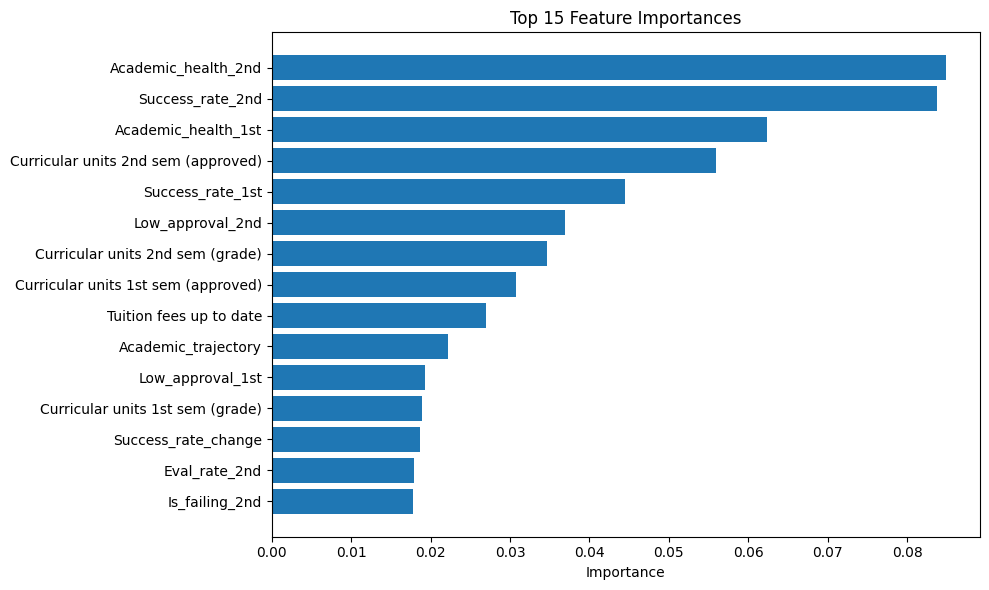

In [100]:
# ============================================================================
# 9. FEATURE IMPORTANCE (LIHAT FITUR PALING PENTING)
# ============================================================================
print("\n" + "="*60)
print("TOP 15 FEATURE IMPORTANCES")
print("="*60)

feature_names = numeric_columns + binary_columns + nominal_columns
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

for i in range(min(15, len(feature_names))):
    print(f"{i+1:2d}. {feature_names[indices[i]]:40s} : {importances[indices[i]]:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(15), importances[indices[:15]][::-1])
plt.yticks(range(15), [feature_names[i] for i in indices[:15]][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [101]:
# ============================================================================
# 10. THRESHOLD TUNING UNTUK ENROLLED
# ============================================================================
print("\n" + "="*60)
print("THRESHOLD TUNING UNTUK ENROLLED")
print("="*60)

y_proba = best_model.predict_proba(X_test_final)
enrolled_idx = 1

thresholds = np.arange(0.3, 0.7, 0.02)
best_thresh = 0.5
best_f1 = 0

for thresh in thresholds:
    y_pred_thresh = (y_proba[:, enrolled_idx] >= thresh).astype(int)
    f1 = f1_score((y_test == enrolled_idx).astype(int), y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"Best threshold untuk Enrolled: {best_thresh:.2f}")
print(f"F1 Enrolled di threshold ini: {best_f1:.4f}")

# Terapkan threshold ke prediksi final
y_pred_final = best_model.predict(X_test_final)
enrolled_proba = y_proba[:, enrolled_idx]
y_pred_final[enrolled_proba >= best_thresh] = enrolled_idx

print("\n" + "="*60)
print("HASIL AKHIR DENGAN THRESHOLD TUNING")
print("="*60)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))


THRESHOLD TUNING UNTUK ENROLLED
Best threshold untuk Enrolled: 0.34
F1 Enrolled di threshold ini: 0.5353

HASIL AKHIR DENGAN THRESHOLD TUNING
              precision    recall  f1-score   support

     Dropout       0.85      0.63      0.72       284
    Enrolled       0.44      0.69      0.54       159
    Graduate       0.85      0.82      0.83       442

    accuracy                           0.73       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.78      0.73      0.74       885

